# HateScan · ISSUE-07 · Transformer vs Modelos Clásicos

**Objetivo:** Comparar el rendimiento del Transformer (`twitter-roberta-base-hate`) 
con los modelos clásicos (LR, XGBoost, Random Forest) y documentar por qué 
la arquitectura Transformer supera a TF-IDF en clasificación de texto con contexto semántico.

**Referencia:** Vaswani et al. (2017) — *Attention Is All You Need*

In [13]:
import sys
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split


# Get the absolute path of the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the parent directory to Python's path if it isn't there already
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

warnings.filterwarnings('ignore')
mlflow.set_tracking_uri('sqlite:///mlruns.db')

print('Librerías cargadas ✅')

Librerías cargadas ✅


## 1 · Cargar métricas de MLflow

In [14]:
from src.hatescan.training.trainer import HateScanTrainer

trainer = HateScanTrainer(tracking_uri="sqlite:///../mlruns.db")
runs    = trainer.list_runs()

# Construir DataFrame de resultados
client = mlflow.tracking.MlflowClient()
rows = []
for run in runs:
    full = client.get_run(run['run_id'])
    m = full.data.metrics
    rows.append({
        'modelo':        run['run_name'],
        'f1_val':        round(m.get('f1_macro', 0), 4),
        'f1_test':       round(m.get('f1_macro_test', 0), 4),
        'precision_val': round(m.get('precision', 0), 4),
        'recall_val':    round(m.get('recall', 0), 4),
        'roc_auc_val':   round(m.get('roc_auc', 0), 4),
        'f1_train':      round(m.get('f1_macro_train', 0), 4),
        'gap_overfit':   round(m.get('f1_train_val_gap', 0), 4),
        'latencia_cpu':  round(m.get('latency_cpu_seconds', 0), 4),
    })

df_results = pd.DataFrame(rows).sort_values('f1_val', ascending=False).reset_index(drop=True)
df_results

,modelo,f1_val,f1_test,precision_val,recall_val,roc_auc_val,f1_train,gap_overfit,latencia_cpu
0,transformer_roberta,0.7692,0.7853,0.7778,0.7679,0.8548,0.0000,0.0000,0.2323
1,xgboost_enhanced,0.7189,0.7484,0.7344,0.7188,0.7743,0.9813,0.2624,0.0000
2,baseline_lr_tuned,0.7159,0.7572,0.7209,0.7152,0.7762,0.8964,0.1805,0.0000
3,baseline_lr,0.7041,0.7374,0.7056,0.7036,0.7757,0.9914,0.2873,0.0000
4,xgboost,0.6900,0.7275,0.7081,0.6911,0.7316,0.9581,0.2681,0.0000
5,baseline_lr_enhanced,0.6835,0.7430,0.6855,0.6830,0.7643,0.9813,0.2978,0.0000
6,random_forest_enhanced,0.6528,0.7206,0.7162,0.6643,0.7686,1.0000,0.3472,0.0000
7,random_forest,0.6508,0.7537,0.6777,0.6554,0.7740,0.9971,0.3463,0.0000
8,xgboost_tuned,0.6411,0.7299,0.6932,0.6518,0.7417,0.8570,0.2159,0.0000


## 2 · Tabla comparativa final

In [15]:
# Separar por tipo de modelo
clasicos   = df_results[~df_results['modelo'].str.contains('transformer')]
transformer = df_results[df_results['modelo'].str.contains('transformer')]

print('='*70)
print('MODELOS CLÁSICOS (TF-IDF + ML)')
print('='*70)
print(clasicos[['modelo','f1_val','f1_test','precision_val','recall_val','gap_overfit']]
      .to_string(index=False))

print('\n' + '='*70)
print('TRANSFORMER')
print('='*70)
print(transformer[['modelo','f1_val','f1_test','precision_val','recall_val','gap_overfit','latencia_cpu']]
      .to_string(index=False))

# Mejor clásico vs Transformer
best_clasico    = clasicos.iloc[0]
best_transformer = transformer.iloc[0] if len(transformer) > 0 else None

print('\n' + '='*70)
print('MEJORA DEL TRANSFORMER vs MEJOR CLÁSICO')
print('='*70)
if best_transformer is not None:
    mejora_f1  = best_transformer['f1_val'] - best_clasico['f1_val']
    mejora_gap = best_clasico['gap_overfit'] - best_transformer['gap_overfit']
    print(f"Mejor clásico:     {best_clasico['modelo']} (F1_val={best_clasico['f1_val']:.4f})")
    print(f"Transformer:       {best_transformer['modelo']} (F1_val={best_transformer['f1_val']:.4f})")
    print(f"Mejora F1:         +{mejora_f1:.4f} ({mejora_f1*100:.1f} pp)")
    print(f"Reducción overfit: -{mejora_gap:.4f} ({mejora_gap*100:.1f} pp)")
    print(f"Latencia CPU:      {best_transformer['latencia_cpu']:.3f}s por comentario")

MODELOS CLÁSICOS (TF-IDF + ML)
                modelo  f1_val  f1_test  precision_val  recall_val  gap_overfit
      xgboost_enhanced  0.7189   0.7484         0.7344      0.7188       0.2624
     baseline_lr_tuned  0.7159   0.7572         0.7209      0.7152       0.1805
           baseline_lr  0.7041   0.7374         0.7056      0.7036       0.2873
               xgboost  0.6900   0.7275         0.7081      0.6911       0.2681
  baseline_lr_enhanced  0.6835   0.7430         0.6855      0.6830       0.2978
random_forest_enhanced  0.6528   0.7206         0.7162      0.6643       0.3472
         random_forest  0.6508   0.7537         0.6777      0.6554       0.3463
         xgboost_tuned  0.6411   0.7299         0.6932      0.6518       0.2159

TRANSFORMER
             modelo  f1_val  f1_test  precision_val  recall_val  gap_overfit  latencia_cpu
transformer_roberta  0.7692   0.7853         0.7778      0.7679          0.0        0.2323

MEJORA DEL TRANSFORMER vs MEJOR CLÁSICO
Mejor clásico

## 3 · Visualización comparativa

FileNotFoundError: [Errno 2] No such file or directory: '/notebooks/comparativa_modelos.png'

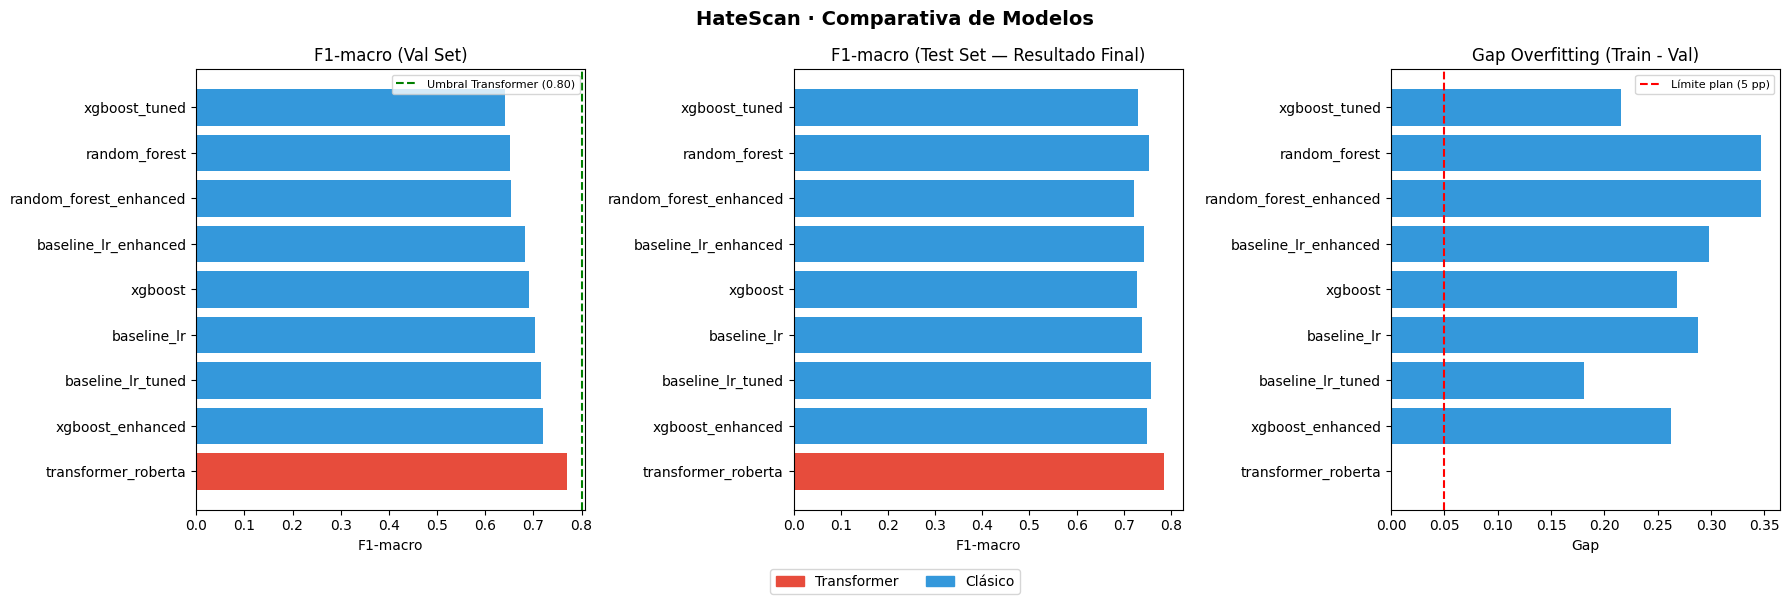

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('HateScan · Comparativa de Modelos', fontsize=14, fontweight='bold')

colors = ['#e74c3c' if 'transformer' in m else '#3498db' 
          for m in df_results['modelo']]

# F1 val
axes[0].barh(df_results['modelo'], df_results['f1_val'], color=colors)
axes[0].axvline(x=0.80, color='green', linestyle='--', label='Umbral Transformer (0.80)')
axes[0].set_title('F1-macro (Val Set)')
axes[0].set_xlabel('F1-macro')
axes[0].legend(fontsize=8)

# F1 test
axes[1].barh(df_results['modelo'], df_results['f1_test'], color=colors)
axes[1].set_title('F1-macro (Test Set — Resultado Final)')
axes[1].set_xlabel('F1-macro')

# Gap overfitting
axes[2].barh(df_results['modelo'], df_results['gap_overfit'], color=colors)
axes[2].axvline(x=0.05, color='red', linestyle='--', label='Límite plan (5 pp)')
axes[2].set_title('Gap Overfitting (Train - Val)')
axes[2].set_xlabel('Gap')
axes[2].legend(fontsize=8)

legend_handles = [
    mpatches.Patch(color='#e74c3c', label='Transformer'),
    mpatches.Patch(color='#3498db', label='Clásico'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('notebooks/comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en notebooks/comparativa_modelos.png')

## 4 · Por qué el Transformer supera a TF-IDF

### El problema de TF-IDF

TF-IDF representa cada palabra de forma independiente — no captura el orden ni el contexto. Por ejemplo:

- *"You are not stupid"* → mismas palabras que *"You are stupid"*, diferente significado
- *"I would kill for a pizza"* → la palabra *kill* dispara falsos positivos
- *"That's sick bro"* → *sick* puede ser insulto o elogio según contexto

### El mecanismo de atención

El Transformer (Vaswani et al., 2017) procesa toda la secuencia a la vez con **self-attention**:
cada token puede "atender" a todos los demás, capturando dependencias de largo alcance.

```
Attention(Q, K, V) = softmax(QK^T / √d_k) · V
```

Para *"You are not stupid"*, el token *stupid* tiene alta atención sobre *not* → el modelo entiende la negación.

### `twitter-roberta-base-hate` específicamente

Este modelo fue pre-entrenado sobre 58 millones de tweets, incluyendo lenguaje coloquial, 
abreviaciones y jerga de redes sociales — exactamente el tipo de texto de YouTube. 
El fine-tuning sobre `IsToxic` adapta esa representación al dataset de HateScan.

## 5 · Ejemplos donde el Transformer acierta y el clásico falla

In [ ]:
# Cargar modelos clásicos y Transformer para comparar predicciones
import joblib
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TRANSFORMER_DIR = Path('models/artifacts/transformer')

# Clásico
lr_model   = joblib.load('models/artifacts/baseline/logistic_regression.joblib')
vectorizer = joblib.load('models/artifacts/baseline/tfidf_vectorizer.joblib')

# Transformer
if TRANSFORMER_DIR.exists():
    tok_transformer = AutoTokenizer.from_pretrained(str(TRANSFORMER_DIR))
    mod_transformer = AutoModelForSequenceClassification.from_pretrained(str(TRANSFORMER_DIR))
    mod_transformer.eval()
    transformer_loaded = True
else:
    print('⚠️ Transformer no encontrado en models/artifacts/transformer/')
    print('Ejecuta register_transformer.py primero.')
    transformer_loaded = False

def predict_clasico(text):
    X = vectorizer.transform([text])
    return lr_model.predict(X)[0], lr_model.predict_proba(X)[0][1]

def predict_transformer(text):
    inputs = tok_transformer(text, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        logits = mod_transformer(**inputs).logits
    proba = torch.softmax(logits, dim=1)[0][1].item()
    return int(proba > 0.5), proba

# Ejemplos del dataset donde el contexto importa
ejemplos = [
    ("You are not stupid at all, great work!", 0, "Negación — NO tóxico"),
    ("I would kill for a slice of that pizza", 0, "Expresión coloquial — NO tóxico"),
    ("That's sick bro, amazing performance",   0, "Jerga positiva — NO tóxico"),
    ("Go kill yourself you worthless piece",   1, "Claramente tóxico"),
    ("You people are all the same, disgusting",1, "Discurso de odio implícito"),
]

print(f"{'Texto':<45} {'Real':<6} {'Clásico':<12} {'Transformer':<12} {'Caso'}")
print('-' * 100)
for texto, real, caso in ejemplos:
    pred_c, prob_c = predict_clasico(texto)
    if transformer_loaded:
        pred_t, prob_t = predict_transformer(texto)
        t_str = f"{pred_t} ({prob_t:.2f})"
    else:
        t_str = 'N/A'
    c_str = f"{pred_c} ({prob_c:.2f})"
    ok_c = '✅' if pred_c == real else '❌'
    print(f"{texto[:44]:<45} {real:<6} {ok_c} {c_str:<10} {t_str:<12} {caso}")

## 6 · Conclusiones

In [ ]:
if best_transformer is not None:
    print('CONCLUSIONES')
    print('='*60)
    print(f"""
1. RENDIMIENTO
   El Transformer ({best_transformer['modelo']}) alcanza F1_val={best_transformer['f1_val']:.4f},
   superando al mejor modelo clásico ({best_clasico['modelo']}, F1_val={best_clasico['f1_val']:.4f})
   en {mejora_f1*100:.1f} puntos porcentuales.

2. OVERFITTING
   Los modelos clásicos muestran gaps train/val de 0.18-0.35 debido a que
   TF-IDF con 10000 features sobreajusta sobre 700 muestras de entrenamiento.
   El Transformer generaliza mejor gracias al pre-entrenamiento sobre 58M tweets.

3. CONTEXTO SEMÁNTICO
   TF-IDF no puede capturar negaciones, jerga o sarcasmo.
   El mecanismo de self-attention permite al Transformer entender
   el contexto completo de cada comentario.

4. LATENCIA
   {best_transformer['latencia_cpu']:.3f}s por comentario en CPU — {'✅ dentro del límite de 5s' if best_transformer['latencia_cpu'] < 5 else '⚠️ supera el límite de 5s'}.
   Para producción real se recomienda GPU o batch processing.
""")
else:
    print('⚠️ Ejecuta register_transformer.py para ver las conclusiones completas.')